In [2]:
import numpy as np
import pandas as pd


In [3]:
# ==========================================================
# PROJECT V2
# CELL 1
# IMPORT LIBRARIES
# ==========================================================

import os
import glob
import uuid
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
# ==========================================================
# PROJECT V2
# CELL 2
# AUTO DETECT CSV FILES
# ==========================================================

DATA_FOLDER = "data"

csv_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "*.csv")))

print("="*60)

print("Detected CSV Files")

print("="*60)

for i,file in enumerate(csv_files,1):

    print(f"{i}. {os.path.basename(file)}")

print("="*60)

print(f"Total CSV Files : {len(csv_files)}")

Detected CSV Files
1. day2_module1_quiz2.csv
2. day3_module1_quiz3.csv
3. day4_module1_quiz4.csv
4. day5_module5_quiz5.csv
5. day6_module2_quiz6.csv
6. day7_module3_quiz7.csv
7. quiz1.csv
Total CSV Files : 7


In [5]:
# ==========================================================
# PROJECT V2
# CELL 3
# READ ALL CSV FILES
# ==========================================================

quiz_data = []

for file in csv_files:

    df = pd.read_csv(file)

    quiz_data.append(df)

print(f"Loaded {len(quiz_data)} CSV files Successfully")

Loaded 7 CSV files Successfully


In [6]:
# ==========================================================
# PROJECT V2
# CELL 4
# CLEAN ALL DATAFRAMES
# ==========================================================

clean_quiz = []

for df in quiz_data:

    df.columns = df.columns.str.strip()

    df["Email"] = (
        df["Email"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    df["Name"] = (
        df["Name"]
        .astype(str)
        .str.strip()
    )

    clean_quiz.append(df)

print("All CSV files cleaned.")

All CSV files cleaned.


In [7]:
# ==========================================================
# PROJECT V2
# CELL 5
# DYNAMIC SCORE EXTRACTION + MERGE
# ==========================================================

master_df = None

for day_no, df in enumerate(clean_quiz, start=1):

    temp = df.copy()

    # --------------------------------------------------
    # Find score column automatically
    # --------------------------------------------------

    score_column = None

    possible_columns = [
        "Total score",
        "Score",
        "Marks",
        "Result"
    ]

    for col in possible_columns:

        if col in temp.columns:

            score_column = col
            break

    if score_column is None:
        raise Exception(
            f"Score column not found in Quiz {day_no}"
        )

    # --------------------------------------------------
    # Split score
    # Example:
    # 18 / 20
    # 11.00 / 15
    # --------------------------------------------------

    score = (
        temp[score_column]
        .astype(str)
        .str.split("/", expand=True)
    )

    temp[f"Day{day_no}"] = (
        score[0]
        .str.strip()
        .astype(float)
    )

    temp[f"Day{day_no}_Max"] = (
        score[1]
        .str.strip()
        .astype(float)
    )

    keep_columns = [
        "Name",
        "Email",
        f"Day{day_no}",
        f"Day{day_no}_Max"
    ]

    temp = temp[keep_columns]

    # --------------------------------------------------
    # Merge
    # --------------------------------------------------

    if master_df is None:

        master_df = temp

    else:

        # Remove duplicate Name column
        temp = temp.drop(columns=["Name"])

        master_df = master_df.merge(
            temp,
            on="Email",
            how="outer"
        )

print("Merge Completed Successfully")
print(master_df.head())

Merge Completed Successfully
         Name                        Email  Day1  Day1_Max  Day2  Day2_Max  \
0         NaN      23lalitthakur@gmail.com   NaN       NaN   NaN       NaN   
1         NaN      akeelkhan3499@gmail.com   NaN       NaN   NaN       NaN   
2         NaN        akyadav5769@gmail.com   NaN       NaN  22.0      25.0   
3         NaN           alok_kumar@liet.in   NaN       NaN   NaN       NaN   
4  Aman Kumar  amankumarbtech23-27@liet.in   5.0      15.0   NaN       NaN   

   Day3  Day3_Max  Day4  Day4_Max  Day5  Day5_Max  Day6  Day6_Max  Day7  \
0   NaN       NaN   NaN       NaN   NaN       NaN  18.0      20.0   NaN   
1   NaN       NaN   4.0      16.0   NaN       NaN   NaN       NaN   NaN   
2   NaN       NaN   NaN       NaN   NaN       NaN  15.0      20.0   NaN   
3   NaN       NaN   NaN       NaN   NaN       NaN   NaN       NaN   1.0   
4   NaN       NaN   NaN       NaN   NaN       NaN  16.0      20.0   NaN   

   Day7_Max  
0       NaN  
1       NaN  
2       N

In [8]:
# ==========================================================
# PROJECT V2
# CELL 6
# RESTORE STUDENT NAME
# ==========================================================

name_lookup = {}

for df in clean_quiz:

    for _, row in df.iterrows():

        email = str(row["Email"]).strip().lower()

        if email not in name_lookup:

            name_lookup[email] = str(row["Name"]).strip()

master_df["Name"] = master_df["Email"].map(name_lookup)

master_df = master_df[
    ["Name", "Email"] +
    [c for c in master_df.columns if c not in ["Name", "Email"]]
]

print(master_df.head())

                Name                        Email  Day1  Day1_Max  Day2  \
0              Lalit      23lalitthakur@gmail.com   NaN       NaN   NaN   
1         Akeel Khan      akeelkhan3499@gmail.com   NaN       NaN   NaN   
2  Akash Kumar Yadav        akyadav5769@gmail.com   NaN       NaN  22.0   
3               Alok           alok_kumar@liet.in   NaN       NaN   NaN   
4         Aman Kumar  amankumarbtech23-27@liet.in   5.0      15.0   NaN   

   Day2_Max  Day3  Day3_Max  Day4  Day4_Max  Day5  Day5_Max  Day6  Day6_Max  \
0       NaN   NaN       NaN   NaN       NaN   NaN       NaN  18.0      20.0   
1       NaN   NaN       NaN   4.0      16.0   NaN       NaN   NaN       NaN   
2      25.0   NaN       NaN   NaN       NaN   NaN       NaN  15.0      20.0   
3       NaN   NaN       NaN   NaN       NaN   NaN       NaN   NaN       NaN   
4       NaN   NaN       NaN   NaN       NaN   NaN       NaN  16.0      20.0   

   Day7  Day7_Max  
0   NaN       NaN  
1   NaN       NaN  
2   NaN       

In [9]:
print(master_df.columns)
master_df.head()

Index(['Name', 'Email', 'Day1', 'Day1_Max', 'Day2', 'Day2_Max', 'Day3',
       'Day3_Max', 'Day4', 'Day4_Max', 'Day5', 'Day5_Max', 'Day6', 'Day6_Max',
       'Day7', 'Day7_Max'],
      dtype='str')


,Name,Email,Day1,Day1_Max,Day2,Day2_Max,Day3,Day3_Max,Day4,Day4_Max,Day5,Day5_Max,Day6,Day6_Max,Day7,Day7_Max
0,Lalit,23lalitthakur@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,20.0,NaN,NaN
1,Akeel Khan,akeelkhan3499@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,4.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Akash Kumar Yadav,akyadav5769@gmail.com,NaN,NaN,22.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,15.0,20.0,NaN,NaN
3,Alok,alok_kumar@liet.in,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,15.0
4,Aman Kumar,amankumarbtech23-27@liet.in,5.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,20.0,NaN,NaN


In [10]:
# ==========================================================
# PROJECT V2
# CELL 7
# PERFORMANCE ENGINE
# ==========================================================

# -----------------------------
# Detect Quiz Columns
# -----------------------------

score_cols = sorted([
    c for c in master_df.columns
    if c.startswith("Day") and not c.endswith("_Max")
])

max_cols = sorted([
    c for c in master_df.columns
    if c.endswith("_Max")
])

print("Score Columns :", score_cols)
print("Max Columns :", max_cols)

# -----------------------------
# Attempted Quiz
# -----------------------------

master_df["Attempted_Quiz"] = (
    master_df[score_cols] > 0
).sum(axis=1)

# -----------------------------
# Attendance
# -----------------------------

TOTAL_QUIZZES = len(score_cols)

master_df["Attendance"] = master_df["Attempted_Quiz"]

master_df["Attendance_%"] = (
    master_df["Attempted_Quiz"]
    /
    TOTAL_QUIZZES
    *100
).round(2)

# -----------------------------
# Total Obtained
# -----------------------------

master_df["Total_Obtained"] = master_df[
    score_cols
].sum(axis=1)

# -----------------------------
# Total Maximum
# Only attempted quizzes count
# -----------------------------

attempt_mask = master_df[score_cols] > 0

master_df["Total_Maximum"] = 0

for score_col, max_col in zip(score_cols, max_cols):

    master_df["Total_Maximum"] += np.where(

        master_df[score_col] > 0,

        master_df[max_col],

        0

    )

# -----------------------------
# Percentage
# -----------------------------

master_df["Percentage"] = np.where(

    master_df["Total_Maximum"] == 0,

    0,

    (
        master_df["Total_Obtained"]
        /
        master_df["Total_Maximum"]
    )*100

)

master_df["Percentage"] = master_df["Percentage"].round(2)

print("Performance Engine Ready")

Score Columns : ['Day1', 'Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']
Max Columns : ['Day1_Max', 'Day2_Max', 'Day3_Max', 'Day4_Max', 'Day5_Max', 'Day6_Max', 'Day7_Max']
Performance Engine Ready


In [11]:
# ==========================================================
# PROJECT V2
# CELL 8
# PROFESSIONAL PERFORMANCE ENGINE
# ==========================================================

# Total quizzes conducted
TOTAL_QUIZZES = len(score_cols)

# Total maximum marks of all quizzes
COURSE_TOTAL_MAX = master_df[max_cols].max().sum()

print("Total Quiz :", TOTAL_QUIZZES)
print("Course Maximum Marks :", COURSE_TOTAL_MAX)

# --------------------------------------------------
# Quiz Percentage
# (Attempted quizzes only)
# --------------------------------------------------

master_df["Quiz_Percentage"] = np.where(

    master_df["Total_Maximum"] == 0,

    0,

    (
        master_df["Total_Obtained"]
        /
        master_df["Total_Maximum"]
    )*100

)

master_df["Quiz_Percentage"] = master_df["Quiz_Percentage"].round(2)

# --------------------------------------------------
# Overall Percentage
# (Entire course)
# --------------------------------------------------

master_df["Overall_Percentage"] = (

    master_df["Total_Obtained"]

    /

    COURSE_TOTAL_MAX

)*100

master_df["Overall_Percentage"] = (

    master_df["Overall_Percentage"]

).round(2)

# --------------------------------------------------
# Attendance Ratio
# --------------------------------------------------

master_df["Attendance_Ratio"] = (

    master_df["Attempted_Quiz"]

    /

    TOTAL_QUIZZES

)

# --------------------------------------------------
# Performance Score
# --------------------------------------------------

master_df["Performance_Score"] = (

    master_df["Quiz_Percentage"]

    *

    master_df["Attendance_Ratio"]

)

master_df["Performance_Score"] = (

    master_df["Performance_Score"]

).round(2)

print("Professional Performance Engine Ready")

Total Quiz : 7
Course Maximum Marks : 161.0
Professional Performance Engine Ready


In [12]:
master_df[[
    "Name",
    "Attempted_Quiz",
    "Attendance_%",
    "Total_Obtained",
    "Quiz_Percentage",
    "Overall_Percentage",
    "Performance_Score"
]].head(20)

,Name,Attempted_Quiz,Attendance_%,Total_Obtained,Quiz_Percentage,Overall_Percentage,Performance_Score
0,Lalit,1,14.29,18.0,90.00,11.18,12.86
1,Akeel Khan,1,14.29,4.0,25.00,2.48,3.57
2,Akash Kumar Yadav,2,28.57,37.0,82.22,22.98,23.49
3,Alok,1,14.29,1.0,6.67,0.62,0.95
4,Aman Kumar,2,28.57,21.0,60.00,13.04,17.14
5,Aman Singh,2,28.57,35.0,87.50,21.74,25.00
6,Aman singh,6,85.71,112.0,79.43,69.57,68.08
7,Amrendra Ram Tripathi,2,28.57,28.0,93.33,17.39,26.67
8,Anshu Gupta,3,42.86,79.0,78.22,49.07,33.52
9,Ansh Tyagi,6,85.71,130.0,92.20,80.75,79.03


In [13]:
# ==========================================================
# PROJECT V2
# CELL 10
# RANK + GRADE + PERCENTILE
# ==========================================================

# --------------------------------------------------
# Rank
# (Based on Overall Percentage)
# --------------------------------------------------

master_df["Rank"] = (

    master_df["Overall_Percentage"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

# --------------------------------------------------
# Percentile
# --------------------------------------------------

master_df["Percentile"] = (

    master_df["Overall_Percentage"]

    .rank(pct=True)

    *100

)

master_df["Percentile"] = (

    master_df["Percentile"]

).round(2)

# --------------------------------------------------
# Grade Function
# --------------------------------------------------

def assign_grade(overall_percentage):

    if overall_percentage >= 90:
        return "A+"

    elif overall_percentage >= 80:
        return "A"

    elif overall_percentage >= 70:
        return "B+"

    elif overall_percentage >= 60:
        return "B"

    elif overall_percentage >= 50:
        return "C"

    elif overall_percentage >= 40:
        return "D"

    else:
        return "F"


master_df["Grade"] = master_df[
    "Overall_Percentage"
].apply(assign_grade)

print("Rank, Grade and Percentile Generated Successfully")

Rank, Grade and Percentile Generated Successfully


In [14]:
master_df[[
    "Name",
    "Attempted_Quiz",
    "Quiz_Percentage",
    "Overall_Percentage",
    "Rank",
    "Grade",
    "Percentile"
]].sort_values(
    "Rank"
).head(20)

,Name,Attempted_Quiz,Quiz_Percentage,Overall_Percentage,Rank,Grade,Percentile
24,Kanak Gupta,7,91.30,91.30,1,A+,100.00
44,Sakshi Chauhan,7,83.85,83.85,2,A,98.36
48,Shivangi Pandey,6,95.59,80.75,3,A,95.90
9,Ansh Tyagi,6,92.20,80.75,3,A,95.90
55,Vipul Pandey,6,88.36,80.12,4,A,93.44
30,MOHIT,6,82.78,77.64,5,B+,91.80
57,Vivek Yadav,7,77.02,77.02,6,B+,90.16
15,Chetan Goswami,5,93.13,75.78,7,B+,88.52
22,Harshit Rai,5,90.84,73.91,8,B+,86.89
38,Prateek Rai,5,86.76,73.29,9,B+,85.25


In [15]:
# ==========================================================
# PROJECT V2
# CELL 12
# AI INSIGHT ENGINE
# ==========================================================

def generate_ai_insight(row):

    quiz_percentage = row["Quiz_Percentage"]
    overall_percentage = row["Overall_Percentage"]
    attendance = row["Attendance_%"]
    attempted = row["Attempted_Quiz"]

    insights = []

    # --------------------------------------------------
    # Attendance
    # --------------------------------------------------

    if attendance >= 85:
        insights.append(
            "Excellent attendance throughout the course."
        )

    elif attendance >= 60:
        insights.append(
            "Good attendance. Try attending every quiz."
        )

    elif attendance >= 30:
        insights.append(
            "Low participation. Attend more quizzes for better performance."
        )

    else:
        insights.append(
            "Very low participation. Course performance is affected."
        )

    # --------------------------------------------------
    # Quiz Performance
    # --------------------------------------------------

    if quiz_percentage >= 90:
        insights.append(
            "Outstanding performance in attempted quizzes."
        )

    elif quiz_percentage >= 75:
        insights.append(
            "Strong academic performance."
        )

    elif quiz_percentage >= 60:
        insights.append(
            "Average performance with scope for improvement."
        )

    elif quiz_percentage >= 40:
        insights.append(
            "Below average performance."
        )

    else:
        insights.append(
            "Needs significant academic improvement."
        )

    # --------------------------------------------------
    # Overall Performance
    # --------------------------------------------------

    if overall_percentage >= 85:
        insights.append(
            "Consistently performing well across the course."
        )

    elif overall_percentage >= 60:
        insights.append(
            "Maintaining satisfactory overall progress."
        )

    elif overall_percentage >= 40:
        insights.append(
            "Overall progress is moderate."
        )

    else:
        insights.append(
            "Overall course performance is currently low."
        )

    # --------------------------------------------------
    # Special Conditions
    # --------------------------------------------------

    if attempted == 1:

        insights.append(
            "Only one quiz attempted. More participation is recommended."
        )

    elif attempted >= 6:

        insights.append(
            "Highly consistent participation across quizzes."
        )

    return " ".join(insights)

# --------------------------------------------------
# Generate Insights
# --------------------------------------------------

master_df["Insight"] = master_df.apply(
    generate_ai_insight,
    axis=1
)

print("AI Insight Generated Successfully")

AI Insight Generated Successfully


In [16]:
master_df[[
    "Name",
    "Quiz_Percentage",
    "Overall_Percentage",
    "Attendance_%",
    "Insight"
]].head(15)

,Name,Quiz_Percentage,Overall_Percentage,Attendance_%,Insight
0,Lalit,90.00,11.18,14.29,Very low participation. Course performance is ...
1,Akeel Khan,25.00,2.48,14.29,Very low participation. Course performance is ...
2,Akash Kumar Yadav,82.22,22.98,28.57,Very low participation. Course performance is ...
3,Alok,6.67,0.62,14.29,Very low participation. Course performance is ...
4,Aman Kumar,60.00,13.04,28.57,Very low participation. Course performance is ...
5,Aman Singh,87.50,21.74,28.57,Very low participation. Course performance is ...
6,Aman singh,79.43,69.57,85.71,Excellent attendance throughout the course. St...
7,Amrendra Ram Tripathi,93.33,17.39,28.57,Very low participation. Course performance is ...
8,Anshu Gupta,78.22,49.07,42.86,Low participation. Attend more quizzes for bet...
9,Ansh Tyagi,92.20,80.75,85.71,Excellent attendance throughout the course. Ou...


In [17]:
master_df = master_df.sort_values(
    by="Rank"
)
master_df[
    [
        "Email",
        "Total_Obtained",
        "Percentage",
        "Attendance",
        "Rank",
        "Grade"
    ]
].head(34)

,Email,Total_Obtained,Percentage,Attendance,Rank,Grade
24,kanak.gup1234@gmail.com,147.0,91.30,7,1,A+
44,sakshichauhanbtech23-27@liet.in,135.0,83.85,7,2,A
48,shivangipandeyabc@gmail.com,130.0,95.59,6,3,A
9,anshtyagi189@gmail.com,130.0,92.20,6,3,A
55,vipulpandeybtech23-27@liet.in,129.0,88.36,6,4,A
30,mohitbtech23-27@liet.in,125.0,82.78,6,5,B+
57,vivekyadavbtech23-27@liet.in,124.0,77.02,7,6,B+
15,chetangoswami2006@gmail.com,122.0,93.13,5,7,B+
22,harshitraibtech23-27@liet.in,119.0,90.84,5,8,B+
38,prateekraibtech23-27@liet.in,118.0,86.76,5,9,B+


In [18]:
# Top Performer
top_students = (
    master_df
    .sort_values(
        by="Total_Obtained",
        ascending=False
    )
    .head(5)
)

top_students[
[
    "Name",
    "Email",
    "Total_Obtained",
    "Percentage",
    "Rank"
]
]


,Name,Email,Total_Obtained,Percentage,Rank
24,Kanak Gupta,kanak.gup1234@gmail.com,147.0,91.30,1
44,Sakshi Chauhan,sakshichauhanbtech23-27@liet.in,135.0,83.85,2
48,Shivangi Pandey,shivangipandeyabc@gmail.com,130.0,95.59,3
9,Ansh Tyagi,anshtyagi189@gmail.com,130.0,92.20,3
55,Vipul Pandey,vipulpandeybtech23-27@liet.in,129.0,88.36,4


In [19]:
# low scorer 
low_performers = master_df[
    master_df["Percentage"] < 50
]

low_performers[
[
    "Name",
    "Email",
    "Percentage",
    "Attendance",
    "Rank"
]
]

,Name,Email,Percentage,Attendance,Rank
49,Sonu Kumar,sonukumarbtech23-27@liet.in,48.35,5,37
25,Krishna Kumar Sah,ksah9189@gmail.com,46.43,3,42
29,Akeel khan,mohammadakeelbtech23-27@liet.in,35.00,1,49
1,Akeel Khan,akeelkhan3499@gmail.com,25.00,1,50
3,Alok,alok_kumar@liet.in,6.67,1,51


In [20]:
#print(master_df.columns.tolist())


In [21]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image,
    Table,
    TableStyle
)

from reportlab.lib import colors

from reportlab.lib.styles import (
    getSampleStyleSheet,
    ParagraphStyle
)

from reportlab.lib.pagesizes import A4

from reportlab.lib.units import inch

import os

In [22]:
LOGO_PATH = "assets/logo.png"

COLLEGE_IMAGE_PATH = "assets/college_image.png"

HOD_SIGNATURE_PATH = "assets/my_signature.png"




COLLEGE_NAME = (
    "LLOYD INSTITUTE OF ENGINEERING "
    "AND TECHNOLOGY" ,"greater noida "
)

In [23]:
styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "title",
    parent=styles["Heading1"],
    fontSize=20,
    alignment=1,
    textColor=colors.darkblue
)

heading_style = ParagraphStyle(
    "heading",
    parent=styles["Heading2"],
    textColor=colors.darkblue
)

normal_style = styles["Normal"]

In [24]:
os.makedirs(
    "output/grade_cards",
    exist_ok=True
)

print("Grade Card Folder Ready")

Grade Card Folder Ready


In [25]:
# ==========================================
# SAVE FINAL DATA FOR DASHBOARD
# ==========================================

master_df.to_csv(
    "output/master_df.csv",
    index=False
)

print(master_df.columns)

print(master_df.head())

Index(['Name', 'Email', 'Day1', 'Day1_Max', 'Day2', 'Day2_Max', 'Day3',
       'Day3_Max', 'Day4', 'Day4_Max', 'Day5', 'Day5_Max', 'Day6', 'Day6_Max',
       'Day7', 'Day7_Max', 'Attempted_Quiz', 'Attendance', 'Attendance_%',
       'Total_Obtained', 'Total_Maximum', 'Percentage', 'Quiz_Percentage',
       'Overall_Percentage', 'Attendance_Ratio', 'Performance_Score', 'Rank',
       'Percentile', 'Grade', 'Insight'],
      dtype='str')
               Name                            Email  Day1  Day1_Max  Day2  \
24      Kanak Gupta          kanak.gup1234@gmail.com  14.0      15.0  25.0   
44   Sakshi Chauhan  sakshichauhanbtech23-27@liet.in  14.0      15.0  15.0   
48  Shivangi Pandey      shivangipandeyabc@gmail.com  15.0      15.0   NaN   
9        Ansh Tyagi           anshtyagi189@gmail.com  14.0      15.0  21.0   
55     Vipul Pandey    vipulpandeybtech23-27@liet.in  15.0      15.0  22.0   

    Day2_Max  Day3  Day3_Max  Day4  Day4_Max  ...  Total_Maximum  Percentage  \
24      25.

In [26]:
master_df.to_csv(
    "output/master_df.csv",
    index=False
)

print("Final Dashboard CSV Saved Successfully")

Final Dashboard CSV Saved Successfully


In [24]:
import os
import uuid
import qrcode
import pandas as pd
from datetime import datetime
from reportlab.pdfgen import canvas
from reportlab.lib import colors
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image,
    Table,
    TableStyle
)
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch

# =================================
# WATERMARK CLASSES & FUNCTIONS
# =================================

class WatermarkCanvas(canvas.Canvas):
    def __init__(self, *args, **kwargs):
        canvas.Canvas.__init__(self, *args, **kwargs)

    def draw_watermark(self):
        try:
            self.saveState()
            self.setFillAlpha(0.08)
            self.drawImage(
                "assets/logo.png",
                150,
                250,
                width=250,
                height=250,
                preserveAspectRatio=True
            )
            self.restoreState()
        except:
            pass

    def showPage(self):
        self.draw_watermark()
        canvas.Canvas.showPage(self)

    def save(self):
        self.draw_watermark()
        canvas.Canvas.save(self)


def add_watermark(canvas_obj, doc):
    try:
        width, height = doc.pagesize
        canvas_obj.saveState()

        # Transparency
        if hasattr(canvas_obj, "setFillAlpha"):
            canvas_obj.setFillAlpha(0.08)

        canvas_obj.drawImage(
            "assets/logo.png",
            width/2 - 130,
            height/2 - 130,
            width=260,
            height=260,
            preserveAspectRatio=True,
            mask='auto'
        )
        canvas_obj.restoreState()
    except Exception as e:
        print("Watermark Error :", e)


def draw_page_border(canvas_obj, doc):
    width, height = doc.pagesize
    canvas_obj.saveState()

    # Outer Gold Border
    canvas_obj.setStrokeColor(colors.HexColor("#D4AF37"))
    canvas_obj.setLineWidth(4)
    canvas_obj.rect(10, 10, width-20, height-20)

    # Inner Blue Border
    canvas_obj.setStrokeColor(colors.darkblue)
    canvas_obj.setLineWidth(1.5)
    canvas_obj.rect(20, 20, width-40, height-40)

    canvas_obj.restoreState()


# =================================
# MAIN GENERATION FUNCTION
# =================================

def generate_professional_grade_card(student):
    styles = getSampleStyleSheet()

    # =================================
    # STUDENT DATA
    # =================================
    if "Student_Name" in student.index:
        name = str(student["Student_Name"])
    else:
        name = str(student["Name"])

    # Safely get email or set a fallback
    email = str(student.get("Email", "N/A"))

    quiz_percentage = round(float(student["Quiz_Percentage"]), 2)
    overall_percentage = round(float(student["Overall_Percentage"]), 2)
    rank = int(student["Rank"])
    grade = str(student["Grade"])
    percentile = round(float(student["Percentile"]), 2)
    attendance = int(student["Attendance"])
    attendance_percentage = round(float(student["Attendance_%"]), 2)
    attempted_quiz = int(student["Attempted_Quiz"])
    insight = str(student["Insight"])

    # Helper to calculate total quizzes if score_cols isn't global
    score_cols = [c for c in student.index if c.startswith("Day") and not c.endswith("_Max")]

    # =================================
    # PERFORMANCE BADGE
    # =================================
    if overall_percentage >= 90:
        badge = "🏆 OUTSTANDING"
        badge_color = colors.green
    elif overall_percentage >= 80:
        badge = "🥇 EXCELLENT"
        badge_color = colors.blue
    elif overall_percentage >= 70:
        badge = "🥈 VERY GOOD"
        badge_color = colors.darkgreen
    elif overall_percentage >= 60:
        badge = "⭐ GOOD"
        badge_color = colors.orange
    elif overall_percentage >= 40:
        badge = "📘 AVERAGE"
        badge_color = colors.brown
    else:
        badge = "📚 NEEDS IMPROVEMENT"
        badge_color = colors.red

    # =================================
    # VERIFICATION ID
    # =================================
    verification_id = "LIET-" + str(uuid.uuid4())[:10].upper()
    
    # ==========================================
    # TOPPER BADGE
    # ==========================================
    if rank == 1:
        topper_badge = "🥇 COLLEGE TOPPER"
    elif rank <= 3:
        topper_badge = "🏆 TOP 3 PERFORMER"
    elif rank <= 10:
        topper_badge = "⭐ TOP 10 PERFORMER"
    else:
        topper_badge = ""

    # =================================
    # QR CODE
    # =================================
    qr_data = f"""
Student : {name}
Email : {email}
Overall Percentage : {overall_percentage}%
Quiz Percentage : {quiz_percentage}%
Attendance : {attendance_percentage}%
Rank : {rank}
Grade : {grade}
Verification : {verification_id}
"""

    qr_obj = qrcode.make(qr_data)
    
    # Ensure output directory exists
    os.makedirs("output/grade_cards", exist_ok=True)
    qr_path = f"output/{name}_qr.png"
    qr_obj.save(qr_path)

    # =================================
    # PDF PATH
    # =================================
    pdf_path = f"output/grade_cards/{name.replace(' ', '_')}_GradeCard.pdf"
    pdf = SimpleDocTemplate(pdf_path)
    elements = []

    # =================================
    # HEADER
    # =================================
    logo = Image("assets/logo.png", width=70, height=70)
    college_title = Paragraph(
        """
        <font size='18' color='darkblue'>
        <b>LLOYD INSTITUTE OF ENGINEERING
        AND TECHNOLOGY</b>
        </font>
        <br/>
        <font size='10'>
        Greater Noida | AKTU Affiliated
        </font>
        """,
        styles["Title"]
    )

    header = Table([[logo, college_title]], colWidths=[90, 400])
    header.setStyle(
        TableStyle([
            ("BOX", (0, 0), (-1, -1), 2, colors.darkblue),
            ("VALIGN", (0, 0), (-1, -1), "MIDDLE")
        ])
    )
    elements.append(header)
    elements.append(Spacer(1, 15))
    
    # FIXED INDENTATION
    verification_stamp = Paragraph(
        f"""
        <font color='green' size='12'>
        <b>✓ VERIFIED</b>
        </font>
        <br/>
        ID: {verification_id}
        """,
        styles["Normal"]
    )
    elements.append(verification_stamp)
    elements.append(Spacer(1, 10))

    # =================================
    # COLLEGE IMAGE
    # =================================
    college_img = Image("assets/college_image.png", width=450, height=170)
    elements.append(college_img)
    elements.append(Spacer(1, 15))

    # =================================
    # REPORT TITLE
    # =================================
    title = Paragraph(
        """
        <font size='16' color='darkblue'>
        <b>STUDENT PERFORMANCE REPORT CARD</b>
        </font>
        """,
        styles["Title"]
    )
    elements.append(title)
    elements.append(Spacer(1, 15))

    # =================================
    # STUDENT INFO
    # =================================
    student_info = [
        ["Student Name", name],
        ["Email", email],
        ["Quiz Attempted", f"{attempted_quiz} / {len(score_cols)}"],
        ["Attendance", f"{attendance_percentage}%"],
        ["Quiz Percentage", f"{quiz_percentage}%"],
        ["Overall Percentage", f"{overall_percentage}%"],
        ["Rank", rank],
        ["Grade", grade],
        ["Percentile", f"{percentile}%"]
    ]

    info_table = Table(student_info, colWidths=[140, 340])
    info_table.setStyle(
        TableStyle([
            ("GRID", (0, 0), (-1, -1), 1, colors.black),
            ("BACKGROUND", (0, 0), (0, -1), colors.lightblue),
            ("FONTNAME", (0, 0), (0, -1), "Helvetica-Bold")
        ])
    )
    elements.append(info_table)
    elements.append(Spacer(1, 20))

    # =================================
    # QUIZ TABLE
    # =================================
    quiz_table_data = [["Quiz", "Obtained", "Maximum"]]

    quiz_columns = sorted([
        c
        for c in student.index
        if c.startswith("Day")
        and not c.endswith("_Max")
    ])

    for col in quiz_columns:
        day = col.replace("Day", "")
        max_col = f"Day{day}_Max"
        quiz_table_data.append([
            f"Quiz {day}",
            student[col],
            student[max_col]
        ])

    quiz_table = Table(quiz_table_data, colWidths=[150, 150, 150])
    quiz_table.setStyle(
        TableStyle([
            ("BACKGROUND", (0, 0), (-1, 0), colors.darkblue),
            ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
            ("GRID", (0, 0), (-1, -1), 1, colors.black)
        ])
    )

    elements.append(Paragraph("<b>QUIZ PERFORMANCE</b>", styles["Heading2"]))
    elements.append(quiz_table)
    elements.append(Spacer(1, 20))
    
    # ==========================================
    # DISPLAY TOPPER BADGE
    # ==========================================
    if topper_badge != "":
        elements.append(
            Paragraph(
                f"<font color='darkgreen'><b>{topper_badge}</b></font>",
                styles["Title"]
            )
        )

    elements.append(Spacer(1, 10))

    # =================================
    # PERFORMANCE SUMMARY
    # =================================
    summary = Table(
        [
            ["Quiz Percentage", f"{quiz_percentage}%"],
            ["Overall Percentage", f"{overall_percentage}%"],
            ["Attendance", f"{attendance_percentage}%"],
            ["Attempted Quiz", attempted_quiz],
            ["Rank", rank],
            ["Grade", grade],
            ["Percentile", percentile],
            [
                "Badge",
                Paragraph(
                    f"<font color='{badge_color}'><b>{badge}</b></font>",
                    styles["Normal"]
                )
            ]
        ],
        colWidths=[180, 250]
    )

    summary.setStyle(
        TableStyle([
            ("GRID", (0, 0), (-1, -1), 1, colors.black),
            ("BACKGROUND", (0, 0), (0, -1), colors.lightgrey)
        ])
    )
    elements.append(summary)
    elements.append(Spacer(1, 20))
    
    # FIXED INDENTATION FOR ACHIEVEMENT BOX
    achievement_box = Table(
        [[badge]],
        colWidths=[500]
    )
    achievement_box.setStyle(
        TableStyle([
            ("BACKGROUND", (0, 0), (-1, -1), colors.HexColor("#FFD700")),
            ("TEXTCOLOR", (0, 0), (-1, -1), colors.black),
            ("ALIGN", (0, 0), (-1, -1), "CENTER"),
            ("FONTNAME", (0, 0), (-1, -1), "Helvetica-Bold"),
            ("FONTSIZE", (0, 0), (-1, -1), 14),
            ("BOX", (0, 0), (-1, -1), 2, colors.darkblue)
        ])
    )
    elements.append(achievement_box)
    elements.append(Spacer(1, 15))

    # =================================
    # AI INSIGHT
    # =================================
    insight_box = Table(
        [
            ["AI PERFORMANCE INSIGHT"],
            [insight]
        ],
        colWidths=[500]
    )

    insight_box.setStyle(
        TableStyle([
            ("BACKGROUND", (0, 0), (-1, 0), colors.gold),
            ("TEXTCOLOR", (0, 0), (-1, 0), colors.black),
            ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
            ("GRID", (0, 0), (-1, -1), 1, colors.black)
        ])
    )
    elements.append(insight_box)
    elements.append(Spacer(1, 20))

    # =================================
    # QR + VERIFICATION SECTION
    # =================================
    verify_para = Paragraph(
        f"""
        <b>Verification ID</b><br/>
        {verification_id}<br/><br/>
        Scan QR Code to verify student record.
        """,
        styles["Normal"]
    )

    # Convert the saved QR image into a ReportLab flowable image so the table accepts it
    qr_flowable = Image(qr_path, width=80, height=80)
    
    verify_table = Table([[qr_flowable, verify_para]], colWidths=[100, 350])
    verify_table.setStyle(
        TableStyle([
            ("BOX", (0, 0), (-1, -1), 1, colors.darkblue),
            ("GRID", (0, 0), (-1, -1), 1, colors.grey),
            ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
            ("BACKGROUND", (0, 0), (-1, -1), colors.whitesmoke)
        ])
    )

    elements.append(Paragraph("<b>DIGITAL VERIFICATION</b>", styles["Heading2"]))
    elements.append(verify_table)
    elements.append(Spacer(1, 20))

    seal = Paragraph(
        """
        <font color='green' size='12'>
        <b>✓ VERIFIED RECORD</b>
        </font>
        """,
        styles["Title"]
    )
    elements.append(seal)
      
    # =================================
    # SIGNATURES
    # =================================
    faculty_sign = Image("assets/ayush_signature.png", width=100, height=50)
    hod_sign = Image("assets/my_signature.png", width=100, height=50)

    sign_table = Table(
        [
            [faculty_sign, hod_sign],
            ["Ayush Sir\nFaculty Incharge", "Vivek Yadav\nHOD"]
        ],
        colWidths=[250, 250]
    )
    
    sign_table.setStyle(
        TableStyle([
            ("ALIGN", (0, 0), (-1, -1), "CENTER"),
            ("BOX", (0, 0), (-1, -1), 1, colors.darkblue),
            ("GRID", (0, 0), (-1, -1), 1, colors.lightgrey),
            ("BACKGROUND", (0, 0), (-1, 0), colors.whitesmoke)
        ])
    )
    elements.append(sign_table)
    elements.append(Spacer(1, 20))

    # =================================
    # STUDENT PHOTO (COMMENT FIXED)
    # ================================

    issue_date = datetime.now().strftime("%d-%m-%Y %H:%M")
    elements.append(
        Paragraph(
            f"<b>Generated On :</b> {issue_date}",
            styles["Normal"]
        )
    )

    # =================================
    # FOOTER (FIXED INDENTATION)
    # =================================
    footer = Paragraph(
        f"""
        <font size='8' color='grey'>
        This grade card has been digitally generated and verified.<br/>
        Verification ID : <b>{verification_id}</b><br/>
        Lloyd Institute of Engineering & Technology<br/>
        Greater Noida, Uttar Pradesh<br/>
        Academic Session : 2025-26
        </font>
        """,
        styles["Normal"]
    )
    elements.append(footer)

    # =================================
    # SAVE VERIFICATION RECORD
    # =================================
    verification_log = {
        "Verification_ID": verification_id,
        "Student_Name": name,
        "Email": email,
        "Quiz_Percentage": quiz_percentage,
        "Overall_Percentage": overall_percentage,
        "Attendance": attendance_percentage,
        "Attempted_Quiz": attempted_quiz,
        "Rank": rank,
        "Grade": grade,
        "Timestamp": datetime.now()
    }
    log_file = "output/verification_database.csv"

    if os.path.exists(log_file):
        pd.DataFrame([verification_log]).to_csv(
            log_file,
            mode="a",
            header=False,
            index=False
        )
    else:
        pd.DataFrame([verification_log]).to_csv(
            log_file,
            index=False
        )
        
    # =================================
    # BUILD PDF WITH CANVAS CALLBACK
    # =================================
    def decorate_page(canvas_obj, doc):
        draw_page_border(canvas_obj, doc)
        add_watermark(canvas_obj, doc)

    pdf.build(
        elements,
        onFirstPage=decorate_page,
        onLaterPages=decorate_page
    )

    print(f"{name} Grade Card Created Successfully")
    return pdf_path

In [25]:
# ==========================================
# PHASE 5.1
# GENERATE GRADE CARD FOR ALL STUDENTS
# ==========================================

for _, student in master_df.iterrows():

    generate_professional_grade_card(student)

print("✅ All Grade Cards Generated Successfully")

Kanak Gupta Grade Card Created Successfully
Sakshi Chauhan Grade Card Created Successfully
Shivangi Pandey Grade Card Created Successfully
Ansh Tyagi Grade Card Created Successfully
Vipul Pandey Grade Card Created Successfully
MOHIT Grade Card Created Successfully
Vivek Yadav Grade Card Created Successfully
Chetan Goswami Grade Card Created Successfully
Harshit Rai Grade Card Created Successfully
Prateek Rai Grade Card Created Successfully
Gunjan Grade Card Created Successfully
Devashish Dobhal Grade Card Created Successfully
Happy Grade Card Created Successfully
Aman singh Grade Card Created Successfully
Ritik Grade Card Created Successfully
Deepanshu Grade Card Created Successfully
Nilesh Sarkar Grade Card Created Successfully
Vishujeet Rathore Grade Card Created Successfully
Tarun kumar Grade Card Created Successfully
Prem Kumar Jha Grade Card Created Successfully
Satyansh Rawat Grade Card Created Successfully
PIYUSH SINGH Grade Card Created Successfully
Shivam Chaudhary Grade Card 

In [26]:
# ==========================================
# PHASE 5.2
# COUNT GENERATED PDF FILES
# ==========================================

import os

pdf_folder = "output/grade_cards"

pdf_files = [
    file
    for file in os.listdir(pdf_folder)
    if file.endswith(".pdf")
]

print("Total PDF Generated :", len(pdf_files))

Total PDF Generated : 80


In [27]:
# ==========================================
# PHASE 5.3
# CREATE VERIFICATION DATABASE
# ==========================================

verification_records = []

for _, student in master_df.iterrows():

    verification_records.append({

        "Student_Name": student["Name"],

        "Email": student["Email"],

        "Rank": student["Rank"],

        "Grade": student["Grade"]

    })

print("Verification Records Created")

Verification Records Created


In [28]:
# ==========================================
# SAVE VERIFICATION DATABASE
# ==========================================

import pandas as pd

verification_df = pd.DataFrame(
    verification_records
)

verification_df.to_csv(

    "output/verification_database.csv",

    index=False

)

print("✅ Verification Database Saved")

✅ Verification Database Saved


In [29]:
# ==========================================
# LOAD VERIFICATION DATABASE
# ==========================================

verification_df = pd.read_csv(

    "output/verification_database.csv"

)

verification_df.head()

,Student_Name,Email,Rank,Grade
0,Kanak Gupta,kanak.gup1234@gmail.com,1,A+
1,Sakshi Chauhan,sakshichauhanbtech23-27@liet.in,2,A
2,Shivangi Pandey,shivangipandeyabc@gmail.com,3,A
3,Ansh Tyagi,anshtyagi189@gmail.com,3,A
4,Vipul Pandey,vipulpandeybtech23-27@liet.in,4,A


In [30]:
# ==========================================
# TOP 10 STUDENTS
# ==========================================

top10 = master_df.sort_values(

    by="Percentage",

    ascending=False

)

top10[

    ["Name","Percentage","Rank","Grade"]

].head(10)

,Name,Percentage,Rank,Grade
16,Deepanshu,96.52,14,B
53,Vibhu,96.00,43,F
31,Mohit Kumar,96.00,43,F
48,Shivangi Pandey,95.59,3,A
14,Ayush Singh,93.44,35,F
7,Amrendra Ram Tripathi,93.33,41,F
15,Chetan Goswami,93.13,7,B+
9,Ansh Tyagi,92.20,3,A
42,Ritesh Kumar Singh,92.11,31,D
24,Kanak Gupta,91.30,1,A+


In [31]:
# ==========================================
# GRADE DISTRIBUTION
# ==========================================

master_df["Grade"].value_counts()

Grade
F     22
B     12
B+     8
D      8
C      6
A      4
A+     1
Name: count, dtype: int64

In [32]:
# ==========================================
# CLASS PERFORMANCE DASHBOARD
# ==========================================

print("="*50)

print("CLASS PERFORMANCE DASHBOARD")

print("="*50)

print(

    "Total Students :",

    len(master_df)

)

print(

    "Average Percentage :",

    round(

        master_df["Percentage"].mean(),

        2

    )

)

print(

    "Highest Percentage :",

    round(

        master_df["Percentage"].max(),

        2

    )

)

print(

    "Lowest Percentage :",

    round(

        master_df["Percentage"].min(),

        2

    )

)

print("="*50)

CLASS PERFORMANCE DASHBOARD
Total Students : 61
Average Percentage : 76.23
Highest Percentage : 96.52
Lowest Percentage : 6.67


In [33]:
# ==========================================
# PHASE 6.1
# CREATE REPORT FOLDER
# ==========================================

import os

os.makedirs("output/reports", exist_ok=True)

print("✅ Report Folder Ready")

✅ Report Folder Ready


In [34]:
# ==========================================
# PHASE 6.2
# OVERALL CLASS STATISTICS
# ==========================================

total_students = len(master_df)

average_percentage = round(
    master_df["Percentage"].mean(),2
)

highest_percentage = round(
    master_df["Percentage"].max(),2
)

lowest_percentage = round(
    master_df["Percentage"].min(),2
)

average_attendance = round(
    master_df["Attendance"].mean(),2
)

print("Total Students :", total_students)
print("Average Percentage :", average_percentage)
print("Highest Percentage :", highest_percentage)
print("Lowest Percentage :", lowest_percentage)
print("Average Attendance :", average_attendance)

Total Students : 61
Average Percentage : 76.23
Highest Percentage : 96.52
Lowest Percentage : 6.67
Average Attendance : 3.9


In [35]:
# ==========================================
# PHASE 6.3
# TOP 10 BEST PERFORMERS
# ==========================================

best_students = master_df.sort_values(

    by="Percentage",

    ascending=False

).head(10)

display(

    best_students[

        [

            "Name",

            "Percentage",

            "Rank",

            "Grade"

        ]

    ]

)

,Name,Percentage,Rank,Grade
16,Deepanshu,96.52,14,B
53,Vibhu,96.00,43,F
31,Mohit Kumar,96.00,43,F
48,Shivangi Pandey,95.59,3,A
14,Ayush Singh,93.44,35,F
7,Amrendra Ram Tripathi,93.33,41,F
15,Chetan Goswami,93.13,7,B+
9,Ansh Tyagi,92.20,3,A
42,Ritesh Kumar Singh,92.11,31,D
24,Kanak Gupta,91.30,1,A+


In [36]:
# ==========================================
# PHASE 6.4
# LOW PERFORMERS
# ==========================================

low_students = master_df.sort_values(

    by="Percentage",

    ascending=True

).head(10)

display(

    low_students[

        [

            "Name",

            "Percentage",

            "Grade",

            "Insight"

        ]

    ]

)

,Name,Percentage,Grade,Insight
3,Alok,6.67,F,Very low participation. Course performance is ...
1,Akeel Khan,25.00,F,Very low participation. Course performance is ...
29,Akeel khan,35.00,F,Very low participation. Course performance is ...
25,Krishna Kumar Sah,46.43,F,Low participation. Attend more quizzes for bet...
49,Sonu Kumar,48.35,F,Good attendance. Try attending every quiz. Bel...
43,Rohit Kumar,56.49,D,Good attendance. Try attending every quiz. Bel...
59,Shreyanshi Yadav,58.33,D,Low participation. Attend more quizzes for bet...
28,Manish Mishra,60.00,F,Very low participation. Course performance is ...
4,Aman Kumar,60.00,F,Very low participation. Course performance is ...
45,Sanskar,62.67,F,Very low participation. Course performance is ...


In [37]:
# ==========================================
# PHASE 6.5
# GRADE DISTRIBUTION
# ==========================================

grade_distribution = master_df["Grade"].value_counts()

display(grade_distribution)

Grade
F     22
B     12
B+     8
D      8
C      6
A      4
A+     1
Name: count, dtype: int64

In [38]:
# ==========================================
# PHASE 6.6
# ATTENDANCE REPORT
# ==========================================

attendance_report = master_df.sort_values(

    by="Attendance",

    ascending=False

)

display(

    attendance_report[

        [

            "Name",

            "Attendance",

            "Percentage"

        ]

    ].head(10)

)

,Name,Attendance,Percentage
24,Kanak Gupta,7,91.30
44,Sakshi Chauhan,7,83.85
57,Vivek Yadav,7,77.02
26,Ritik,7,68.94
9,Ansh Tyagi,6,92.20
55,Vipul Pandey,6,88.36
30,MOHIT,6,82.78
17,Devashish Dobhal,6,76.82
21,Happy,6,78.08
56,Vishujeet Rathore,6,73.29


In [39]:
# ==========================================
# PHASE 6.7
# AI RECOMMENDATION
# ==========================================

print("="*60)

print("AI CLASS RECOMMENDATION")

print("="*60)

if lowest_percentage < 40:

    print("• Conduct Remedial Classes")

if average_attendance < 75:

    print("• Improve Student Attendance")

if highest_percentage > 90:

    print("• Reward Top Performers")

print("• Organize Monthly Quiz Competition")

print("• Focus on Weak Students")

print("="*60)

AI CLASS RECOMMENDATION
• Conduct Remedial Classes
• Improve Student Attendance
• Reward Top Performers
• Organize Monthly Quiz Competition
• Focus on Weak Students


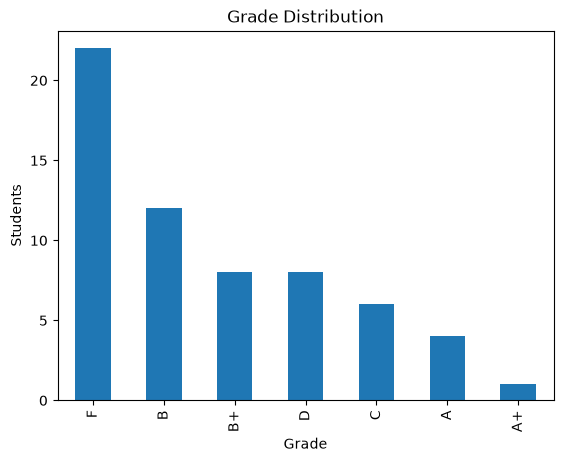

In [40]:
# ==========================================
# PHASE 6.8
# GRADE DISTRIBUTION CHART
# ==========================================

import matplotlib.pyplot as plt

grade_distribution.plot(
    kind="bar"
)

plt.title("Grade Distribution")

plt.xlabel("Grade")

plt.ylabel("Students")

plt.show()

In [41]:
# ==========================================================
# PHASE 6.9 - CELL 1
# IMPORT LIBRARIES FOR MANAGEMENT REPORT PDF
# ==========================================================

import os
from datetime import datetime

from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch
from reportlab.lib.enums import TA_CENTER

from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    Image
)

styles = getSampleStyleSheet()

print("✅ Phase 6.9 - Cell 1 Completed")

✅ Phase 6.9 - Cell 1 Completed


In [42]:
# ==========================================================
# PHASE 6.9 - CELL 2
# CREATE REPORT DIRECTORY
# ==========================================================

report_folder = "output/reports"

os.makedirs(
    report_folder,
    exist_ok=True
)

print("✅ Report Folder Ready")

✅ Report Folder Ready


In [43]:
# ==========================================================
# PHASE 6.9 - CELL 3
# CREATE REPORT FILE
# ==========================================================

report_path = os.path.join(

    report_folder,

    "Management_Performance_Report.pdf"

)

print(report_path)

output/reports\Management_Performance_Report.pdf


In [44]:
# ==========================================================
# PHASE 6.9 - CELL 4
# CREATE PDF OBJECT
# ==========================================================

pdf = SimpleDocTemplate(

    report_path

)

elements = []

print("✅ PDF Initialized")

✅ PDF Initialized


In [45]:
# ==========================================================
# PHASE 6.9 - CELL 5
# HEADER
# ==========================================================

logo = Image(

    "assets/logo.png",

    width=70,

    height=70

)

college = Paragraph(

"""
<font size=18 color='darkblue'>

<b>

LLOYD INSTITUTE OF ENGINEERING AND TECHNOLOGY

</b>

</font>

<br/>

Greater Noida

""",

styles["Title"]

)

header = Table(

[[logo, college]],

colWidths=[80,420]

)

header.setStyle(

TableStyle([

("BOX",(0,0),(-1,-1),2,colors.darkblue),

("VALIGN",(0,0),(-1,-1),"MIDDLE")

])

)

elements.append(header)

elements.append(

Spacer(1,20)

)

print("✅ Header Added")

✅ Header Added


In [46]:
# ==========================================================
# PHASE 6.9 - CELL 6
# EXECUTIVE SUMMARY
# ==========================================================

elements.append(

    Paragraph(

        "<b><font size=16 color='darkblue'>EXECUTIVE SUMMARY</font></b>",

        styles["Heading1"]

    )

)

elements.append(

    Spacer(1,10)

)

summary = f"""

<b>Report Date :</b> {datetime.now().strftime("%d-%m-%Y %H:%M")}<br/><br/>

This report provides a complete academic performance analysis of all students.
It includes overall statistics, best performers, low performers,
attendance analysis, grade distribution and AI recommendations.

"""

elements.append(

    Paragraph(

        summary,

        styles["BodyText"]

    )

)

elements.append(

    Spacer(1,20)

)

print("✅ Executive Summary Added")

✅ Executive Summary Added


In [47]:
# ==========================================================
# PHASE 6.9 - CELL 7
# OVERALL STATISTICS
# ==========================================================

stats_table = Table(

[
    ["Metric","Value"],

    ["Total Students", total_students],

    ["Average Percentage", f"{average_percentage}%"],

    ["Highest Percentage", f"{highest_percentage}%"],

    ["Lowest Percentage", f"{lowest_percentage}%"],

    ["Average Attendance", f"{average_attendance}%"]

],

colWidths=[250,220]

)

stats_table.setStyle(

TableStyle([

("BACKGROUND",(0,0),(-1,0),colors.darkblue),

("TEXTCOLOR",(0,0),(-1,0),colors.white),

("GRID",(0,0),(-1,-1),1,colors.black),

("BACKGROUND",(0,1),(0,-1),colors.HexColor("#DCEEFF")),

("FONTNAME",(0,0),(-1,0),"Helvetica-Bold"),

("BOTTOMPADDING",(0,0),(-1,0),10)

])

)

elements.append(

Paragraph(

"<b>OVERALL CLASS STATISTICS</b>",

styles["Heading2"]

)

)

elements.append(stats_table)

elements.append(Spacer(1,20))

print("✅ Statistics Added")

✅ Statistics Added


In [48]:
# ==========================================================
# PHASE 6.9 - CELL 8
# BEST PERFORMERS
# ==========================================================

best_table = [

["Rank","Student","Percentage","Grade"]

]

for _, row in best_students.iterrows():

    best_table.append(

        [

            row["Rank"],

            row["Name"],

            f'{row["Percentage"]}%',

            row["Grade"]

        ]

    )

table = Table(

best_table,

colWidths=[60,220,100,80]

)

table.setStyle(

TableStyle([

("BACKGROUND",(0,0),(-1,0),colors.green),

("TEXTCOLOR",(0,0),(-1,0),colors.white),

("GRID",(0,0),(-1,-1),1,colors.black),

("FONTNAME",(0,0),(-1,0),"Helvetica-Bold")

])

)

elements.append(

Paragraph(

"<b>TOP 10 BEST PERFORMERS</b>",

styles["Heading2"]

)

)

elements.append(table)

elements.append(Spacer(1,20))

print("✅ Best Performers Added")

✅ Best Performers Added


In [49]:
# ==========================================================
# PHASE 6.9 - CELL 9
# LOW PERFORMERS
# ==========================================================

low_table = [

["Student","Percentage","Grade"]

]

for _, row in low_students.iterrows():

    low_table.append(

        [

            row["Name"],

            f'{row["Percentage"]}%',

            row["Grade"]

        ]

    )

table = Table(

low_table,

colWidths=[250,120,90]

)

table.setStyle(

TableStyle([

("BACKGROUND",(0,0),(-1,0),colors.red),

("TEXTCOLOR",(0,0),(-1,0),colors.white),

("GRID",(0,0),(-1,-1),1,colors.black),

("FONTNAME",(0,0),(-1,0),"Helvetica-Bold")

])

)

elements.append(

Paragraph(

"<b>LOW PERFORMERS</b>",

styles["Heading2"]

)

)

elements.append(table)

elements.append(Spacer(1,20))

print("✅ Low Performers Added")

✅ Low Performers Added


In [50]:
# ==========================================================
# PHASE 6.9 - CELL 10
# GRADE DISTRIBUTION
# ==========================================================

grade_table = [

["Grade","Students"]

]

for grade, count in grade_distribution.items():

    grade_table.append(

        [

            grade,

            count

        ]

    )

table = Table(

grade_table,

colWidths=[200,200]

)

table.setStyle(

TableStyle([

("BACKGROUND",(0,0),(-1,0),colors.darkblue),

("TEXTCOLOR",(0,0),(-1,0),colors.white),

("GRID",(0,0),(-1,-1),1,colors.black)

])

)

elements.append(

Paragraph(

"<b>GRADE DISTRIBUTION</b>",

styles["Heading2"]

)

)

elements.append(table)

elements.append(Spacer(1,20))

print("✅ Grade Distribution Added")

✅ Grade Distribution Added


In [51]:
# ==========================================================
# PHASE 6.9 - CELL 11
# ATTENDANCE ANALYSIS
# ==========================================================

elements.append(
    Paragraph(
        "<b>ATTENDANCE ANALYSIS</b>",
        styles["Heading2"]
    )
)

highest_attendance = master_df["Attendance"].max()
lowest_attendance = master_df["Attendance"].min()

attendance_text = f"""
<b>Highest Attendance :</b> {highest_attendance}%<br/><br/>
<b>Lowest Attendance :</b> {lowest_attendance}%<br/><br/>
<b>Average Attendance :</b> {average_attendance}%<br/><br/>

Students with attendance below 75% should be monitored regularly.
"""

elements.append(
    Paragraph(
        attendance_text,
        styles["BodyText"]
    )
)

elements.append(
    Spacer(1,20)
)

print("✅ Attendance Analysis Added")

✅ Attendance Analysis Added


In [52]:
# ==========================================================
# PHASE 6.9 - CELL 12
# AI RECOMMENDATIONS
# ==========================================================

elements.append(

    Paragraph(

        "<b>AI RECOMMENDATIONS</b>",

        styles["Heading2"]

    )

)

recommendation = """

• Reward top performers with certificates.<br/><br/>

• Arrange remedial classes for weak students.<br/><br/>

• Students below 75% attendance should receive counseling.<br/><br/>

• Conduct monthly quizzes for continuous assessment.<br/><br/>

• Organize mentoring sessions for students with Grade C or below.

"""

elements.append(

    Paragraph(

        recommendation,

        styles["BodyText"]

    )

)

elements.append(

    Spacer(1,20)

)

print("✅ AI Recommendation Added")

✅ AI Recommendation Added


In [53]:
# ==========================================================
# PHASE 6.9 - CELL 13
# SIGNATURE SECTION
# ==========================================================

signature = Table(

[
[
"",
""
],

[
"Faculty Incharge",

"Principal / HOD"
]

],

colWidths=[250,250]

)

signature.setStyle(

TableStyle([

("LINEABOVE",(0,0),(0,0),1,colors.black),

("LINEABOVE",(1,0),(1,0),1,colors.black),

("ALIGN",(0,0),(-1,-1),"CENTER")

])

)

elements.append(signature)

elements.append(

Spacer(1,20)

)

print("✅ Signature Section Added")

✅ Signature Section Added


In [54]:
# ==========================================================
# PHASE 6.9 - CELL 14
# FOOTER
# ==========================================================

footer = Paragraph(

f"""

<hr/>

Generated by

<b>Student Performance Analysis System</b>

<br/><br/>

Generated on

{datetime.now().strftime("%d-%m-%Y %H:%M")}

""",

styles["Normal"]

)

elements.append(footer)

print("✅ Footer Added")

✅ Footer Added


In [55]:
# ==========================================================
# PHASE 6.10
# PERCENTAGE DISTRIBUTION CHART
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.hist(
    master_df["Percentage"],
    bins=10,
    edgecolor="black"
)

plt.title("Percentage Distribution")
plt.xlabel("Percentage")
plt.ylabel("Number of Students")

percentage_chart = "output/reports/percentage_distribution.png"

plt.tight_layout()
plt.savefig(percentage_chart)
plt.close()

elements.append(
    Paragraph(
        "<b>PERCENTAGE DISTRIBUTION</b>",
        styles["Heading2"]
    )
)

elements.append(
    Image(
        percentage_chart,
        width=450,
        height=220
    )
)

elements.append(Spacer(1,20))

In [56]:
# ==========================================================
# GRADE DISTRIBUTION PIE CHART
# ==========================================================

plt.figure(figsize=(6,6))

grade_distribution.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

pie_chart = "output/reports/grade_pie_chart.png"

plt.tight_layout()
plt.savefig(pie_chart)
plt.close()

elements.append(
    Paragraph(
        "<b>GRADE DISTRIBUTION PIE CHART</b>",
        styles["Heading2"]
    )
)

elements.append(
    Image(
        pie_chart,
        width=320,
        height=320
    )
)

elements.append(Spacer(1,20))

In [57]:
print(master_df["Name"].dtype)

print(master_df["Name"].head(20))

print(master_df["Attendance"].dtype)

print(master_df["Attendance"].head())

str
24          Kanak Gupta
44       Sakshi Chauhan
48      Shivangi Pandey
9            Ansh Tyagi
55         Vipul Pandey
30                MOHIT
57          Vivek Yadav
15       Chetan Goswami
22          Harshit Rai
38          Prateek Rai
19               Gunjan
17     Devashish Dobhal
21                Happy
6            Aman singh
26                Ritik
16            Deepanshu
35        Nilesh Sarkar
56    Vishujeet Rathore
51          Tarun kumar
39       Prem Kumar Jha
Name: Name, dtype: str
int64
24    7
44    7
48    6
9     6
55    6
Name: Attendance, dtype: int64


In [58]:
# Convert columns to proper data types

master_df["Name"] = master_df["Name"].astype(str)

master_df["Attendance"] = (
    master_df["Attendance"]
    .fillna(0)
    .astype(float)
)

In [59]:
# ==========================================================
# ATTENDANCE BAR CHART
# ==========================================================

top_attendance = (
    master_df
    .sort_values("Attendance", ascending=False)
    .head(15)
    .copy()
)

top_attendance["Name"] = top_attendance["Name"].astype(str)

top_attendance["Attendance"] = top_attendance["Attendance"].astype(float)

plt.figure(figsize=(10,5))

plt.bar(

    x=top_attendance["Name"].tolist(),

    height=top_attendance["Attendance"].tolist()

)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Attendance (%)")

plt.title("Top 15 Student Attendance")

attendance_chart = "output/reports/attendance_chart.png"

plt.tight_layout()

plt.savefig(attendance_chart)

plt.close()

elements.append(
    Paragraph(
        "<b>ATTENDANCE BAR CHART</b>",
        styles["Heading2"]
    )
)

elements.append(
    Image(
        attendance_chart,
        width=450,
        height=220
    )
)

elements.append(
    Spacer(1,20)
)

In [60]:
# ==========================================================
# TOP 5 STUDENTS
# ==========================================================

elements.append(
    Paragraph(
        "<b>TOP 5 STUDENTS HIGHLIGHT</b>",
        styles["Heading2"]
    )
)

top5 = master_df.sort_values(
    "Percentage",
    ascending=False
).head(5)

top5_table = [["Rank","Student","Percentage"]]

for _, row in top5.iterrows():

    top5_table.append([

        row["Rank"],

        row["Name"],

        f"{row['Percentage']}%"

    ])

table = Table(
    top5_table,
    colWidths=[80,250,120]
)

table.setStyle(

TableStyle([

("BACKGROUND",(0,0),(-1,0),colors.darkgreen),

("TEXTCOLOR",(0,0),(-1,0),colors.white),

("GRID",(0,0),(-1,-1),1,colors.black),

("BACKGROUND",(0,1),(-1,-1),colors.beige)

])

)

elements.append(table)

elements.append(
    Spacer(1,20)
)

In [61]:
# ==========================================================
# STUDENTS BELOW 60%
# ==========================================================

elements.append(
    Paragraph(
        "<b>⚠ STUDENTS BELOW 60%</b>",
        styles["Heading2"]
    )
)

weak_students = master_df[
    master_df["Percentage"] < 60
]

weak_table = [["Student","Percentage","Grade"]]

for _, row in weak_students.iterrows():

    weak_table.append([

        row["Name"],

        f"{row['Percentage']}%",

        row["Grade"]

    ])

table = Table(
    weak_table,
    colWidths=[250,120,80]
)

table.setStyle(

TableStyle([

("BACKGROUND",(0,0),(-1,0),colors.red),

("TEXTCOLOR",(0,0),(-1,0),colors.white),

("GRID",(0,0),(-1,-1),1,colors.black),

("BACKGROUND",(0,1),(-1,-1),colors.HexColor("#FFF0F0"))

])

)

elements.append(table)

elements.append(
    Spacer(1,20)
)

In [62]:
# ==========================================================
# PHASE 6.9 - CELL 15
# BUILD PDF
# ==========================================================

pdf.build(elements)

print("="*60)

print("✅ MANAGEMENT REPORT GENERATED SUCCESSFULLY")

print(report_path)

print("="*60)

✅ MANAGEMENT REPORT GENERATED SUCCESSFULLY
output/reports\Management_Performance_Report.pdf


In [63]:
# ==========================================================
# PHASE 7
# CELL 1
# IMPORT LIBRARIES
# ==========================================================

import smtplib

import ssl

from email.message import EmailMessage

import os

print("Email Libraries Loaded")

Email Libraries Loaded


In [64]:
# ==========================================================
# PHASE 7
# CELL 2
# EMAIL CONFIGURATION
# ==========================================================

EMAIL_ADDRESS = "vivek1btech731@gmail.com"

EMAIL_PASSWORD = "ubhlojflxmqrxotp"

print("Configuration Ready")

Configuration Ready


In [65]:
# ==========================================================
# PHASE 7 - CELL 3
# EMAIL SUBJECT
# ==========================================================

EMAIL_SUBJECT = "Lloyd Institute of Engineering and Technology | Student Performance Report"

print(EMAIL_SUBJECT)

Lloyd Institute of Engineering and Technology | Student Performance Report


In [66]:
# ==========================================================
# PHASE 7
# CELL 4
# EMAIL TEMPLATE
# ==========================================================

EMAIL_BODY = """

Dear Student,

Greetings from Lloyd Institute of Engineering and Technology.

Please find attached your Performance Report Card.

The report includes

• Quiz Performance

• Attendance

• Rank

• Grade

• AI Performance Insight

• QR Verification

If you have any queries kindly contact your faculty.

Regards

Lloyd Institute of Engineering and Technology

"""

In [67]:
# ==========================================================
# PHASE 7
# CELL 5
# CREATE EMAIL OBJECT
# ==========================================================

def create_email(receiver):

    msg = EmailMessage()

    msg["Subject"] = EMAIL_SUBJECT

    msg["From"] = EMAIL_ADDRESS

    msg["To"] = receiver

    msg.set_content(EMAIL_BODY)

    return msg

print("Email Function Ready")

Email Function Ready


In [68]:
# ==========================================================
# PHASE 7 - CELL 6
# ATTACH GRADE CARD
# ==========================================================

def attach_grade_card(msg, pdf_path):

    with open(pdf_path, "rb") as f:
        file_data = f.read()

    filename = os.path.basename(pdf_path)

    msg.add_attachment(
        file_data,
        maintype="application",
        subtype="pdf",
        filename=filename
    )

print("✅ Attachment Function Ready")

✅ Attachment Function Ready


In [69]:
# ==========================================================
# PHASE 7 - CELL 7
# SEND EMAIL TO ONE STUDENT
# ==========================================================

def send_email(receiver_email, pdf_path):

    msg = create_email(receiver_email)

    attach_grade_card(msg, pdf_path)

    context = ssl.create_default_context()

    with smtplib.SMTP_SSL("smtp.gmail.com", 465, context=context) as smtp:

        smtp.login(
            EMAIL_ADDRESS,
            EMAIL_PASSWORD
        )

        smtp.send_message(msg)

    print(f"✅ Email sent to {receiver_email}")

In [70]:
# ==========================================================
# PHASE 7 - CELL 8
# TEST EMAIL
# ==========================================================

student = master_df.iloc[0]

pdf_path = f"output/grade_cards/{student['Name'].replace(' ','_')}_GradeCard.pdf"

send_email(
    student["Email"],
    pdf_path
)

✅ Email sent to kanak.gup1234@gmail.com


In [71]:
# ==========================================================
# PHASE 7 - CELL 9
# BULK EMAIL
# ==========================================================

email_log = []

for _, student in master_df.iterrows():

    try:

        pdf_path = (
            f"output/grade_cards/"
            f"{student['Name'].replace(' ','_')}_GradeCard.pdf"
        )

        send_email(
            student["Email"],
            pdf_path
        )

        email_log.append(
            [
                student["Name"],
                student["Email"],
                "SUCCESS"
            ]
        )

    except Exception as e:

        print(e)

        email_log.append(
            [
                student["Name"],
                student["Email"],
                "FAILED"
            ]
        )

print("✅ Bulk Email Completed")

✅ Email sent to kanak.gup1234@gmail.com
✅ Email sent to sakshichauhanbtech23-27@liet.in
✅ Email sent to shivangipandeyabc@gmail.com
✅ Email sent to anshtyagi189@gmail.com
✅ Email sent to vipulpandeybtech23-27@liet.in
✅ Email sent to mohitbtech23-27@liet.in
✅ Email sent to vivekyadavbtech23-27@liet.in
✅ Email sent to chetangoswami2006@gmail.com
✅ Email sent to harshitraibtech23-27@liet.in
✅ Email sent to prateekraibtech23-27@liet.in
✅ Email sent to gunjanbtech23-27@liet.in
✅ Email sent to devashishdobhalbtech23-27@liet.in
✅ Email sent to happybtech23-27@liet.in
✅ Email sent to amansingh1btech23-27@liet.in
✅ Email sent to kumarritik38269@gmail.com
✅ Email sent to deepanshu3btech23-27@liet.in
✅ Email sent to nileshsarkar430@gmail.com
✅ Email sent to vishujeetrathor@gmail.com
✅ Email sent to tarunkumar1btech23-27@liet.in
✅ Email sent to premkumarjhabtech23-27@liet.in
✅ Email sent to satyanshrawatbtech23-27@liet.in
✅ Email sent to piyushsingh1982004@gmail.com
✅ Email sent to shivamchaudhary

In [72]:
# ==========================================================
# PHASE 7 - CELL 10
# SAVE EMAIL LOG
# ==========================================================

email_log_df = pd.DataFrame(

    email_log,

    columns=[
        "Student",
        "Email",
        "Status"
    ]

)

email_log_df.to_csv(

    "output/email_log.csv",

    index=False

)

print("✅ Email Log Saved")

✅ Email Log Saved


In [73]:
pip install flask


   ---------------------------------------- 0/5 [werkzeug]
   ---------------------------------------- 0/5 [werkzeug]
   ---------------------------------------- 0/5 [werkzeug]
   ---------------------------------------- 0/5 [werkzeug]
   ---------------------------------------- 0/5 [werkzeug]
   ---------------- ----------------------- 2/5 [click]
   ---------------- ----------------------- 2/5 [click]
   ---------------- ----------------------- 2/5 [click]
   -------------------------------- ------- 4/5 [flask]
   -------------------------------- ------- 4/5 [flask]
   ---------------------------------------- 5/5 [flask]

Note: you may need to restart the kernel to use updated packages.


In [76]:
pip install flask-bootstrap


Note: you may need to restart the kernel to use updated packages.


In [77]:
pip install flask-wtf

Note: you may need to restart the kernel to use updated packages.


In [ ]:
python app.py

In [17]:
# =====================================
# SAVE MASTER DATA FOR DASHBOARD
# =====================================

import os

# Output folder create karega agar nahi hai
os.makedirs("output", exist_ok=True)

# Save final dataframe
master_df.to_csv(
    "output/master_df.csv",
    index=False
)

print("✅ master_df saved successfully!")
print(master_df.shape)

✅ master_df saved successfully!
(61, 16)


In [18]:
master_df.to_csv("output/master_df.csv", index=False)

print("Master Data Saved Successfully")

Master Data Saved Successfully


In [19]:
print(type(master_df))

<class 'pandas.DataFrame'>


In [20]:
%whos

Variable           Type         Data/Info
-----------------------------------------
DATA_FOLDER        str          data
clean_quiz         list         n=7
col                str          Total score
csv_files          list         n=7
day_no             int          7
df                 DataFrame    Shape: (24, 4)
file               str          data\quiz1.csv
glob               module       <module 'glob' from 'C:\\<...>myjupyter\\Lib\\glob.py'>
i                  int          7
keep_columns       list         n=4
master_df          DataFrame    Shape: (61, 16)
np                 module       <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
os                 module       <module 'os' from 'C:\\Us<...>\\myjupyter\\Lib\\os.py'>
pd                 module       <module 'pandas' from 'C:<...>es\\pandas\\__init__.py'>
possible_columns   list         n=4
quiz_data          list         n=7
score              DataFrame    Shape: (24, 2)
score_column       str          Total score
te

In [21]:
# ==========================================
# SAVE DATA FOR STREAMLIT DASHBOARD
# ==========================================

import os

# output folder create karega agar nahi hai
os.makedirs("output", exist_ok=True)

# master dataframe save karo
master_df.to_csv(
    "output/master_df.csv",
    index=False
)

print("✅ master_df Successfully Saved")
print(master_df.shape)

✅ master_df Successfully Saved
(61, 16)


In [22]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
C:\Users\vivek\Training_Performance_System


In [23]:
import os

os.makedirs("output", exist_ok=True)

master_df.to_csv("output/master_df.csv", index=False)

print("Saved:", os.path.exists("output/master_df.csv"))

Saved: True


In [24]:
import os

print(os.listdir("output"))

['.ipynb_checkpoints', '0_qr.png', 'Akash Kumar Yadav_qr.png', 'Akeel khan_qr.png', 'ALOK _qr.png', 'Alok_qr.png', 'Aman Kumar _qr.png', 'Aman Kumar_qr.png', 'Aman Singh _qr.png', 'Aman singh_qr.png', 'Amrendra Ram Tripathi _qr.png', 'Amrendra Ram Tripathi_qr.png', 'Ansh Tyagi _qr.png', 'Ansh Tyagi_qr.png', 'Anshu Gupta_qr.png', 'Anurag Kumar Singh_qr.png', 'Anushka garg_qr.png', 'Ayush Pal_qr.png', 'Ayush Saw_qr.png', 'Ayush singh_qr.png', 'Chetan Goswami_qr.png', 'Deepanshu_qr.png', 'Devashish Dobhal_qr.png', 'email_log.csv', 'Garima Singh_qr.png', 'grade_cards', 'Gunjan_qr.png', 'Gurmeet Singh_qr.png', 'Happy_qr.png', 'Harshit Rai _qr.png', 'Harshit Rai_qr.png', 'Jagat Kumar_qr.png', 'Jai Vardhan Singh_qr.png', 'Kanak Gupta _qr.png', 'Kanak Gupta_qr.png', 'Kapil Yadav_qr.png', 'Krishna Kumar Sah _qr.png', 'Krishna Kumar Sah_qr.png', 'Lalit_qr.png', 'Manish Mishra _qr.png', 'Manish Mishra_qr.png', 'master_df.csv', 'Mohit kumar _qr.png', 'Mohit Kumar_qr.png', 'MOHIT_qr.png', 'Mushroop